# Market Regime Analysis

## Objective

Determine under which market environments the Momentum126 strategy performs best.

Research Questions:

- Does momentum perform better in bull markets?
- Does momentum survive bear markets?
- How does volatility affect performance?
- Are there specific market conditions where momentum should be avoided?

Strategy:

- NIFTY 500 Universe
- Momentum126
- Top 20 Stocks
- Equal Weight
- 42-Day Rebalance
- 0.10% Transaction Cost

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

mom126 = (
    close
    .pct_change(126)
    .shift(1)
)

In [2]:
market = (
    close
    .pct_change()
    .mean(axis=1)
)

market_index = (
    1 + market
).cumprod()

In [3]:
market_ma200 = (
    market_index
    .rolling(200)
    .mean()
)

regime = pd.Series(
    np.where(
        market_index > market_ma200,
        "Bull",
        "Bear"
    ),
    index=market_index.index
)

In [4]:
rebalance_dates = close.index[126::42]

strategy_returns = []

for i in range(len(rebalance_dates)-1):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    selected = (
        mom126.loc[start]
        .dropna()
        .nlargest(20)
        .index
    )

    gross = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        - 1
    ).mean()

    strategy_returns.append(gross - 0.001)

strategy_returns = pd.Series(
    strategy_returns,
    index=rebalance_dates[:-1]
)

In [5]:
regime_returns = pd.DataFrame({
    "Return": strategy_returns,
    "Regime": regime.loc[
        strategy_returns.index
    ]
})

regime_returns.head()

,Return,Regime
Date,,
2015-07-07,NaN,Bear
2015-09-03,0.045079,Bear
2015-11-06,0.087841,Bull
2016-01-11,-0.141215,Bull
2016-03-11,0.118566,Bear


In [6]:
summary = regime_returns.groupby(
    "Regime"
)["Return"].agg(
    ["count","mean","std"]
)

summary["Sharpe"] = (
    summary["mean"]
    /
    summary["std"]
)

summary

,count,mean,std,Sharpe
Regime,,,,
Bear,13,0.041963,0.090154,0.465456
Bull,47,0.077465,0.132665,0.583915


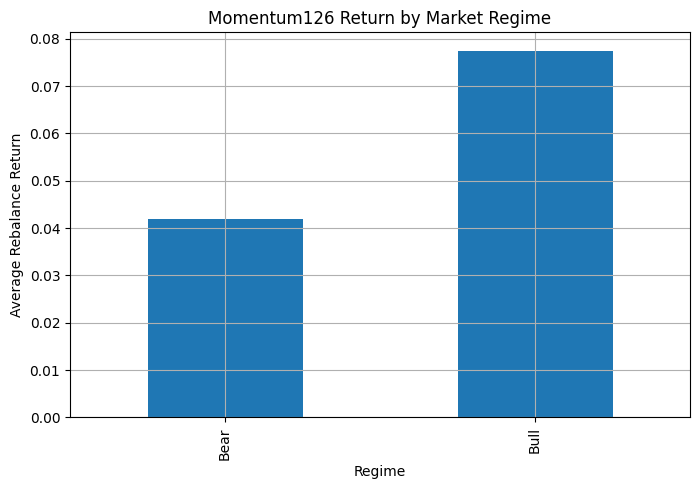

In [7]:
regime_returns.groupby(
    "Regime"
)["Return"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Momentum126 Return by Market Regime"
)

plt.ylabel(
    "Average Rebalance Return"
)

plt.grid(True)

plt.show()

In [8]:
filtered_returns = []

rebalance_dates = close.index[126::42]

for i in range(len(rebalance_dates)-1):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    current_regime = regime.loc[start]

    if current_regime == "Bear":

        filtered_returns.append(0)

        continue

    selected = (
        mom126.loc[start]
        .dropna()
        .nlargest(20)
        .index
    )

    gross = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        - 1
    ).mean()

    filtered_returns.append(
        gross - 0.001
    )

filtered_returns = pd.Series(
    filtered_returns,
    index=rebalance_dates[:-1]
)

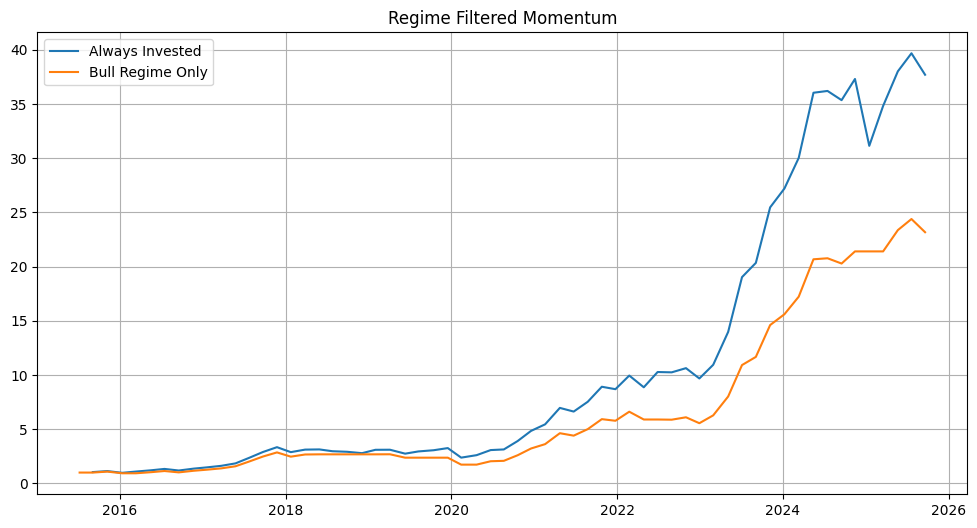

In [12]:
original_equity = (
    1 + strategy_returns
).cumprod()

filtered_equity = (
    1 + filtered_returns
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    original_equity,
    label="Always Invested"
)

plt.plot(
    filtered_equity,
    label="Bull Regime Only"
)

plt.legend()

plt.title(
    "Regime Filtered Momentum"
)

plt.grid(True)

plt.savefig(
    "../results/plots/06_market_regime_returns.png",
    bbox_inches="tight"
)

plt.show()

In [10]:
def metrics(returns):

    equity = (
        1 + returns
    ).cumprod()

    cagr = (
        equity.iloc[-1]
        **
        (
            252 / len(close)
        )
        - 1
    )

    sharpe = (
        returns.mean()
        /
        returns.std()
    ) * np.sqrt(252/42)

    max_dd = (
        equity
        /
        equity.cummax()
        - 1
    ).min()

    return {
        "Total Return":
            equity.iloc[-1]-1,
        "CAGR":
            cagr,
        "Sharpe":
            sharpe,
        "MaxDD":
            max_dd
    }

comparison = pd.DataFrame({
    "Original": metrics(strategy_returns),
    "Bull Only": metrics(filtered_returns)
}).T

comparison

,Total Return,CAGR,Sharpe,MaxDD
Original,36.709834,0.400454,1.368679,-0.288748
Bull Only,22.179160,0.338624,1.211120,-0.394408


In [11]:
summary.to_csv(
    "../results/tables/06_regime_statistics.csv"
)

comparison.to_csv(
    "../results/tables/06_bull_market_filter.csv"
)

## Bull Regime Filter Test

A regime-based momentum filter was tested by only investing during Bull market periods and remaining in cash during Bear market periods.

Results:

| Strategy | CAGR | Sharpe | Max Drawdown |
|----------|--------|--------|--------|
| Original | 40.05% | 1.37 | -28.9% |
| Bull Only | 33.86% | 1.21 | -39.4% |

Findings:

- Momentum remained profitable during both Bull and Bear regimes.
- Removing Bear market exposure reduced overall returns.
- Risk-adjusted performance deteriorated.
- The original strategy outperformed the regime-filtered variant.

Conclusion:

Momentum126 should be traded continuously rather than conditioned on a simple Bull/Bear filter.